In [1]:
# 글자가 사각형(□□)으로 표시되는 '두부(Tofu) 현상' 예방

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

# 폰트 로드 과정에서 발생하는 자잘한 경고 메시지를 숨
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# 실제 폰트 파일이 저장된 경로를 지정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"

# 해당 경로의 파일을 읽어 폰트 속성 객체를 생성
fontprop = fm.FontProperties(fname=fontpath, size=12)

# 핵심 부분. Matplotlib의 기본 폰트를 나눔바른고딕으로 전역 설정
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


### **라이브러리 버전 확인**

In [2]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

3.0.0
2.10.0+cu128
3.10.8


In [3]:
import os
import re
import urllib.request
import tarfile
import sentencepiece as spm  # 구글에서 만든 토큰화 도구
import pandas as pd

import numpy as np
import torch
import torch.nn as nn  # 계층(Layer), 손실 함수(Loss function) 등 모델의 구조를 정의
import torch.optim as optim  # 모델의 오차를 줄여나가는 알고리즘(Adam, SGD 등)을 설정
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset  # 데이터를 모델이 학습하기 좋은 '미니 배치' 단위로 쪼개서 공급

from tqdm import tqdm  # 학습이 얼마나 진행되었는지 시각적인 진행바(Progress Bar)를 보여
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.10.0+cu128


## **Step 1. 데이터 다운로드**

In [4]:
# 데이터 저장 폴더 생성
dataset_dir = os.path.expanduser("datasets")
os.makedirs(dataset_dir, exist_ok=True)


data_folder = os.path.join(dataset_dir, "korean-english-park")
print(data_folder)

filename = "korean-english-park.train.tar.gz"
tar_path = dataset_dir + f"/{filename}"

if not os.path.exists(data_folder):
    print("압축 해제 중...")
    # 'r:gz' 모드로 파일을 엽니다. (read + gzip)
    with tarfile.open(tar_path, 'r:gz') as tar_ref:
        tar_ref.extractall(path=dataset_dir)
    print("압축 해제 완료!")

datasets/korean-english-park
압축 해제 중...
압축 해제 완료!


/tmp/ipykernel_1626/3545391472.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar_ref.extractall(path=dataset_dir)


In [5]:
# 파일 열기
path_ko = f"{dataset_dir}/korean-english-park.train.ko"
path_en = f"{dataset_dir}/korean-english-park.train.en"

with open(path_ko, "r", encoding="utf-8") as f:
    kor_raw = f.read().splitlines()

with open(path_en, "r", encoding="utf-8") as f:
    eng_raw = f.read().splitlines()

In [6]:
# 데이터프레임 생성
df = pd.DataFrame({
    'eng': eng_raw,
    'kor': kor_raw
})

# 결과 확인
print(f"전체 데이터 개수: {len(df)}")
df.head() # 상위 5개 데이터 출력

전체 데이터 개수: 94123


,eng,kor
0,"Much of personal computing is about ""can you t...","개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?"""
1,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2,"Like all optical mice, But it also doesn't nee...",그러나 이것은 또한 책상도 필요로 하지 않는다.
3,uses gyroscopic sensors to control the cursor ...,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분..."
4,Intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...


## **Step 2. 데이터 정제**

In [7]:
# 'eng'와 'kor' 열의 값이 모두 똑같은 행을 찾아 제거합니다.
# inplace=True를 설정해야 원본 데이터프레임(df)에 바로 반영됩니다.
df.drop_duplicates(subset=['eng', 'kor'], inplace=True)
df.drop_duplicates(subset=['eng'], inplace=True)
df.drop_duplicates(subset=['kor'], inplace=True)
# 중복 제거 후 인덱스가 중간중간 비게 되므로, 인덱스를 다시 정렬해주는 것이 좋습니다.
df = df.reset_index(drop=True)

# 결과 확인
print(f"중복 제거 후 데이터 개수: {len(df)}")
df.head()

중복 제거 후 데이터 개수: 74786


,eng,kor
0,"Much of personal computing is about ""can you t...","개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?"""
1,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2,"Like all optical mice, But it also doesn't nee...",그러나 이것은 또한 책상도 필요로 하지 않는다.
3,uses gyroscopic sensors to control the cursor ...,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분..."
4,Intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...


In [8]:
import re

def preprocess_sentence(sentence, is_korean=False):
    sentence = sentence.lower().strip()

    # 1. 구두점 주위에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 2. 언어별 허용 문자 설정
    if is_korean:
        # 한글, 숫자, 주요 구두점만 남기고 제거
        sentence = re.sub(r"[^ㄱ-ㅎ가-힣0-9?.!, ]+", " ", sentence)
    else:
        # 영어 알파벳, 숫자, 주요 구두점만 남기고 제거
        sentence = re.sub(r"[^a-zA-Z0-9?.!, ]+", " ", sentence)

    sentence = sentence.strip()
    return sentence

In [9]:
# df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["kor"].apply(lambda x: preprocess_sentence(x, is_korean=True))

df.head()

,eng,kor
0,much of personal computing is about can you to...,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?"""
1,so a mention a few weeks ago about a rechargea...,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...
2,"like all optical mice , but it also doesn t ne...",그러나 이것은 또한 책상도 필요로 하지 않는다.
3,uses gyroscopic sensors to control the cursor ...,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분..."
4,intelligence officials have revealed a spate o...,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...


In [10]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


## **Step 3. 데이터 토큰화**

#### **영어 SentencePiece 학습 및 토큰화**

In [11]:
eng_vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

# SentencePiece 모델 학습 (타겟이므로 decoder_spm)
spm.SentencePieceTrainer.train(
    input="eng_corpus.txt",
    model_prefix=f"decoder_spm_{eng_vocab_size}",
    vocab_size=eng_vocab_size,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: eng_corpus.txt
  input_format: 
  model_prefix: decoder_spm_3000
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 

In [12]:
decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load(f"decoder_spm_{eng_vocab_size}.model")

True

In [13]:
from konlpy.tag import Mecab
import tensorflow as tf

# 1. 문장을 쪼개주는 형태소 분석기 준비
mecab = Mecab()

# (미리 데이터프레임의 한국어 문장들을 쪼개서 리스트로 만들어 둡니다)
kor_tokens = [mecab.morphs(sentence) for sentence in df['kor']]

# 2. 인코더 토크나이저 정의 (글자를 숫자로 바꾸고 단어장을 관리)
vocab_size = 6000
encoder_tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=vocab_size, 
    oov_token="<unk>" # 단어장에 없는 모르는 단어가 나왔을 때 처리할 이름
)

# 3. 내 데이터(kor_tokens)를 보고 즉석에서 단어장 학습(구축)하기
# SentencePiece의 .train() 과 비슷한 역할입니다.
encoder_tokenizer.fit_on_texts(kor_tokens)

2026-03-10 10:12:21.405070: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 10:12:21.432239: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 10:12:22.255052: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [14]:
eng_sample = df["eng"][1000]
kor_sample = df["kor"][1000]
print(eng_sample)
print(kor_sample)

they call the concept   sustainable development .
그들은 그 개념을 "유지할 수 있는 개발"이라고 부른다.


In [15]:
morphs = mecab.morphs(kor_sample)
enc_token = encoder_tokenizer.texts_to_sequences([morphs])[0]
print(enc_token)

[31, 15, 9, 31, 4715, 6, 51, 556, 38, 45, 14, 5, 374, 51, 472, 1, 2]


In [16]:
enc_decoding = encoder_tokenizer.sequences_to_texts([enc_token])[0]

print(enc_decoding)

그 들 은 그 개념 을 " 유지 할 수 있 는 개발 " 이라고 <unk> .


In [17]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.mecab = Mecab() # 한국어 형태소 분석기 초기화
        
        # 특수 토큰 ID 지정
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    # 전체 데이터 개수 확인
    def __len__(self):
        return len(self.data)

    # 핵심 전처리 및 데이터 반환 (요리해서 내보내기)
    def __getitem__(self, idx):
        # 문장 가져오기
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']

        # 토큰화
        # 한국어: Mecab으로 쪼개고 Keras Tokenizer로 숫자 변환
        morphs = self.mecab.morphs(src_text)
        src_ids = self.encoder_tokenizer.texts_to_sequences([morphs])[0]

        # 영어: SentencePiece로 바로 숫자 변환
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        # Encoder 길이 제한 (max_len 만큼만 사용)
        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]

        # Decoder label 생성
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        # Tensor 변환
        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [18]:
# 학습 비율 설정
train_ratio = 0.8  # 전체 길이의 80%

# 학습 파라미터 설
MAX_LEN = 30 # 문장의 최대 토큰 길이
BATCH_SIZE = 64  # 한 번의 학습에서 사용하는 문장 개수

# 데이터 분할
train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터

# validation 데이터
valid_data = df.drop(train_data.index) # train 데이터로 사용되지 않은 나머지

# index 초기화
train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

# Dataset 객체 생성
train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

# DataLoader 생성
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


## **Step 4. 모델 설계**

In [20]:
class BahdanauAttention(nn.Module):
    # 학습할 가중치(Weight) 준비하기
    def __init__(self, hidden_dim):
        super().__init__()

        # 인코더의 출력값(전체 문장 정보)을 변환하는 가중치
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        
        # 디코더의 현재 상태(지금까지 번역한 정보)를 변환하는 가중치
        self.W2 = nn.Linear(hidden_dim, hidden_dim)

        # W1과 W2를 더해 나온 값을 최종적인 '점수(스칼라값)' 1개로 압축해 주는 가중치
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    # 함수: 실제 어텐션 점수 계산
    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        # 변수에 원본 문장의 길이(단어 개수)를 저장
        src_len = encoder_outputs.shape[0]

        # 차원 늘리기 및 복사
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)

        # 순서 바꾸기
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        # 에너지(Energy) 계산
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)

        # 최종 점수 산출
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        # 확률값으로 변환
        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [21]:
class Encoder(nn.Module):
    # input_dim : 입력 vocabulary 크기
    # emb_dim : embedding 벡터 차원
    # hidden_dim : GRU hidden state 크기
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim) # GRU는 RNN의 한 종류

    def forward(self, src):
        # src : (src_len, batch_size)
        
        # Embedding 적용
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)

        # GRU 통과
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [22]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [23]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = encoder_tokenizer.num_words if encoder_tokenizer.num_words else len(encoder_tokenizer.word_index) + 1
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [25]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [26]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(6000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


## **Step 5. 훈련하기**

### **(1) Optimizer & Loss**

In [27]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


### **(2) train_step 구현하기**

In [28]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


### **(3) 훈련 시작하기**

In [29]:
from nltk.translate.meteor_score import meteor_score
import nltk

# # 최초 1회 실행 (동의어 사전 다운로드)
# nltk.download('wordnet')
# nltk.download('omw-1.4')

In [30]:
def eval_step(model, data_loader, optimizer, criterion, target_vocab):
    model.eval()
    total_loss = 0
    meteor_scores = [] # 점수를 담을 리스트 초기화

    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            # 모델의 입력 순서에 맞게 transpose 변환
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)
    
            outputs,_ = model(src, trg_input)
    
            # --- METEOR 계산을 위한 처리 ---
            pred_indices = outputs.argmax(2).permute(1, 0) 
            target_indices = trg_label.permute(1, 0)
    
            for i in range(pred_indices.shape[0]):
                # 인덱스 -> 단어 리스트 변환 (특수 토큰 제외)
                pred_tokens = [decoder_tokenizer.id_to_piece(idx.item()) for idx in pred_indices[i] if idx.item() not in [0, 1, 2, 3]]
                ref_tokens = [decoder_tokenizer.id_to_piece(idx.item()) for idx in target_indices[i] if idx.item() not in [0, 1, 2, 3]]
    
                if len(pred_tokens) > 0 and len(ref_tokens) > 0:
                    # METEOR는 [정답리스트]와 예측리스트를 인자로 받음
                    score = meteor_score([ref_tokens], pred_tokens)
                    meteor_scores.append(score)
            
            # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)
    
            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

    avg_loss = total_loss / len(data_loader)
    avg_meteor = sum(meteor_scores) / len(meteor_scores) if meteor_scores else 0
    
    return avg_loss, avg_meteor

print("슝~")

슝~


In [31]:
# %%time

# EPOCHS = 10

# # Early Stopping 설정
# patience = 3  # 5번 연속으로 loss가 안 줄어들면 멈춤
# best_valid_loss = float('inf')  # 초기 최고 기록은 무한대로 설정
# patience_counter = 0
# save_model_name = "best_model_A"

# for epoch in range(EPOCHS):
#     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
#     valid_loss, avg_meteor = eval_step(model, validation_loader, optimizer, criterion, decoder_tokenizer)
#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}, Average Meteor: {avg_meteor:.4f}')

#     # 1. 최고 성능 갱신 시 모델 저장
#     if valid_loss < best_valid_loss:
#         print(f"★ Validation Loss 개선: {best_valid_loss:.4f} -> {valid_loss:.4f}. 모델 저장 중...")
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), f'{save_model_name}.pth') # 모델 가중치 저장
#         patience_counter = 0  # 카운터 초기화
        
#     # 2. 성능 개선이 없을 시 Early Stopping 카운트 증가
#     else:
#         patience_counter += 1
#         print(f"Early Stopping 대기... ({patience_counter}/{patience})")
        
#         if patience_counter >= patience:
#             print("🚨 Early Stopping 발동! 학습을 조기 종료합니다.")
#             break

In [32]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    model.eval()
    mecab = Mecab() # 한국어 형태소 분석기
    
    sentence = preprocess_sentence(sentence, is_korean=True)
    morphs = mecab.morphs(sentence)
    src_ids = encoder_tokenizer.texts_to_sequences([morphs])[0]
    
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    # 2. 토큰 ID 추출
    token_ids = [token.item() for token in outputs.argmax(2).squeeze(1)]

    # 3. 디코더(영어) 출력: EOS 토큰(2)에서 자르고 SPM으로 한 번에 텍스트 복원
    eos_id = 2 
    if eos_id in token_ids:
        token_ids = token_ids[:token_ids.index(eos_id)]
        
    result_text = decoder_tokenizer.decode_ids(token_ids)

    return result_text, sentence, attentions.squeeze(1).cpu().numpy()

In [33]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention[:len(predicted_sentence), :len(sentence)], cmap='viridis')

    fontdict = {'fontsize': 12}
    fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
    fontprop = fm.FontProperties(fname=fontpath, size=14)
    
    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, fontproperties=fontprop, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [34]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result.split())

Input: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
Predicted translation: the valentine is not a good thing , and it s not just a few days .


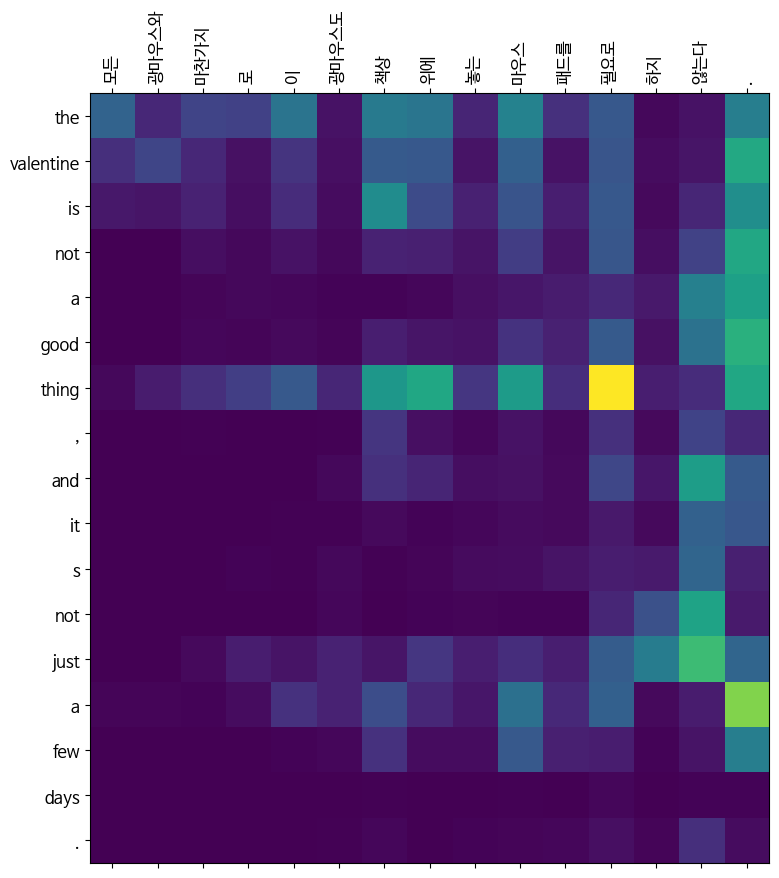

In [35]:
model = Seq2SeqAttention(encoder, decoder, device).to(device)

model.load_state_dict(torch.load('best_model_A.pth', map_location=device))

model.eval()

translate("모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 안녕하세요 . 저희 점심 뭐먹을까요 ?
Predicted translation: we re going to be able to get the  ⁇ 50  ⁇ 


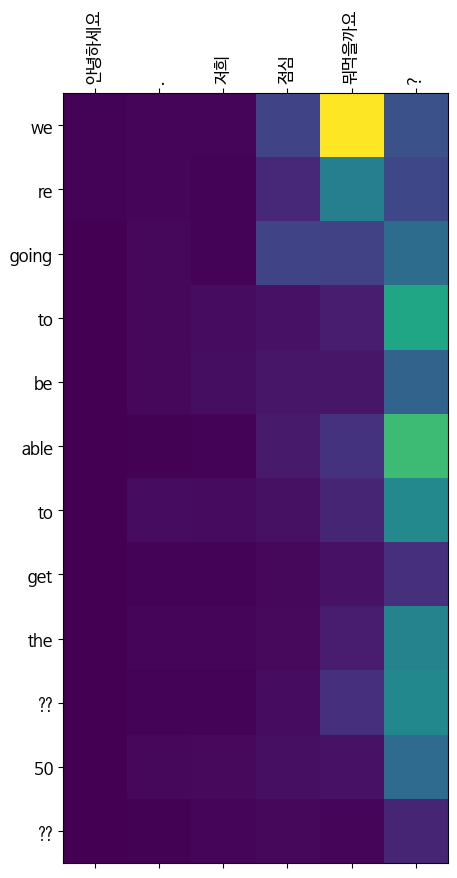

In [36]:
translate("안녕하세요. 저희 점심 뭐먹을까요?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

## 중간 결과
#### Vocab Size
- Encoder Tokenizer Vocab Size : 6,000
- Decoder Tokenizer Vocab Size : 3,000

#### 결과
- Input: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
- Predicted translation: all the size of the country s highest levels of the country s highest level to be the same day , it s not a good

## 결과 해석
- 출력은 잘 되는데, 번역이 전혀 안 되는 것으로 보임
- 최대 평균 Meteor: 0.2837

## 추가 실험
- 양방향(Bidirectional) 인코더 도입
  - 현재 코드는 단뱡향으로 작성돼 있음
- 드롭아웃(Dropout) 추가
- 기울기 클리핑(Gradient Clipping)
  - RNN 기반 모델은 학습하다가 오차(Loss)가 갑자기 팍 튀어버리는 현상이 자주 발생
  - 학습 루프(Train step) 안에 torch.nn.utils.clip_grad_norm_을 한 줄 추가하여 안정화
- '정석 바다나우' 구조로 디코더 리팩토링
  - 어텐션 적용 타이밍: 루옹 스타일

## 실험1 : 양방향(Bidirectional) 인코더 도입

In [37]:
class BidirectionalEncoder(nn.Module):
    # input_dim : 입력 vocabulary 크기
    # emb_dim : embedding 벡터 차원
    # hidden_dim : GRU hidden state 크기
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)

        # 1. bidirectional=True 추가
        self.rnn = nn.GRU(emb_dim, hidden_dim, bidirectional=True) # GRU는 RNN의 한 종류

        # 2. 양방향(2 * hidden_dim)을 다시 원래 크기(hidden_dim)로 압축하는 층
        # 디코더는 hidden_dim 크기 하나만 받을 수 있기 때문
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        
    def forward(self, src):
        # src : (src_len, batch_size)
        
        # Embedding 적용
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)

        # GRU 통과
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        # 3. 마지막 hidden state 처리 (정방향 + 역방향 합치기)
        # hidden[-2,:,:]은 정방향의 마지막, hidden[-1,:,:]은 역방향의 마지막
        combined_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = torch.tanh(self.fc(combined_hidden)) # (batch_size, hidden_dim)으로 압축

        # hidden은 디코더의 초기 입력으로 쓰기 위해 shape를 (1, batch_size, hidden_dim)으로 맞춰줌
        hidden = hidden.unsqueeze(0)

        return outputs, hidden

In [38]:
class BidirectionalDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(BidirectionalDecoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        
        # Decoder RNN은 동일하게 유지 (입력으로 embedding만 받음)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        
        # ★ 수정: 출력층(fc_out)의 입력 차원 변경
        # 기존: hidden_dim + hidden_dim
        # 변경: hidden_dim(디코더 GRU 출력) + (hidden_dim * 2)(양방향 인코더 문맥 벡터)
        self.fc_out = nn.Linear(hidden_dim + (hidden_dim * 2), output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (1, batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim * 2) <- ★ 2배 커짐
        
        input = input.unsqueeze(0)  # (1, batch_size)
        embedded = self.embedding(input)  # (1, batch_size, emb_dim)

        # 1. 어텐션 가중치 계산 (Attention 클래스 내부에서도 *2 처리가 되어있어야 함)
        a = self.attention(hidden[-1], encoder_outputs)  # (batch_size, src_len)

        # 2. 문맥 벡터(Context vector) 계산
        a = a.unsqueeze(1)  # (batch_size, 1, src_len)
        
        # encoder_outputs 가 (batch_size, src_len, hidden_dim * 2)가 됨
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        
        # bmm 결과 context: (batch_size, 1, hidden_dim * 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)  # (1, batch_size, hidden_dim * 2)

        # 3. GRU 통과 (이전 hidden과 현재 단어 입력)
        output, hidden = self.rnn(embedded, hidden)

        # 4. 출력층 결합 및 예측
        output = output.squeeze(0)   # (batch_size, hidden_dim)
        context = context.squeeze(0) # (batch_size, hidden_dim * 2) <- ★ 2배 커진 문맥
        
        # (batch_size, hidden_dim + hidden_dim * 2) -> (batch_size, output_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

In [39]:
class BidirectionalBahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        # ★ 수정: 인코더 출력(W1)이 받는 차원을 hidden_dim * 2로 변경
        # 양방향 인코더의 outputs는 hidden_dim이 2배로 불어나서 들어오기 때문입니다.
        self.W1 = nn.Linear(hidden_dim * 2, hidden_dim)
        
        # 디코더의 hidden state는 여전히 단방향(hidden_dim)이므로 그대로 둡니다.
        self.W2 = nn.Linear(hidden_dim, hidden_dim)

        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim * 2) <- ★ 2배 커진 상태

        src_len = encoder_outputs.shape[0]

        # hidden 차원 늘리기: (batch_size, src_len, hidden_dim)
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)

        # encoder_outputs 차원 변경: (batch_size, src_len, hidden_dim * 2)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        # 에너지 계산 (W1과 W2의 결과값이 모두 hidden_dim으로 맞춰져서 더하기 가능)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))

        # 최종 점수 산출 및 softmax
        attention = self.v(energy).squeeze(2) # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)

In [40]:
import random

class BidirectionalSeq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5, max_len=30, bos_id=1, eos_id=2):
        # src: (src_len, batch_size)
        # trg: (trg_len, batch_size)
        batch_size = src.shape[1]
        
        # 인코더를 통해 encoder_outputs와 hidden(문맥 벡터) 생성
        encoder_outputs, hidden = self.encoder(src)

        outputs = []
        attentions = []

        # 첫 번째 입력은 무조건 <sos> (bos_id)
        input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)

        if trg is not None:
            # [학습 모드]
            for t in range(trg.shape[0]):
                # 현재 input(이전 시점의 정답 혹은 예측값)을 넣어서 현재 단어를 예측
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                
                # 다음 루프의 입력을 결정 (Teacher Forcing)
                top1 = output.argmax(1)
                
                # 확률에 따라 정답(trg[t])을 넣을지, 모델이 예측한 값(top1)을 넣을지 결정
                # ※ 여기서 trg[t]는 모델이 이번 루프에서 맞춰야 했던 정답입니다.
                teacher_force = random.random() < teacher_forcing_ratio
                input = trg[t] if teacher_force else top1
                
        else:
            # [추론 모드]
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                
                top1 = output.argmax(1)
                input = top1 # 모델의 예측값을 다음 입력으로

                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)

        return outputs, attentions

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = encoder_tokenizer.num_words if encoder_tokenizer.num_words else len(encoder_tokenizer.word_index) + 1
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [42]:
encoder = BidirectionalEncoder(input_dim, emb_dim, hid_dim).to(device)
attention = BidirectionalBahdanauAttention(hid_dim).to(device)
decoder = BidirectionalDecoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [43]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


In [44]:
# %%time
# model.train()



# EPOCHS = 10

# # Early Stopping 설정
# patience = 3  # 5번 연속으로 loss가 안 줄어들면 멈춤
# best_valid_loss = float('inf')  # 초기 최고 기록은 무한대로 설정
# patience_counter = 0
# save_model_name = "best_model_B"

# for epoch in range(EPOCHS):
#     train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
#     valid_loss, avg_meteor = eval_step(model, validation_loader, optimizer, criterion, decoder_tokenizer)
#     print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}, Average Meteor: {avg_meteor:.4f}')

#     # 1. 최고 성능 갱신 시 모델 저장
#     if valid_loss < best_valid_loss:
#         print(f"★ Validation Loss 개선: {best_valid_loss:.4f} -> {valid_loss:.4f}. 모델 저장 중...")
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), f'{save_model_name}.pth') # 모델 가중치 저장
#         patience_counter = 0  # 카운터 초기화
        
#     # 2. 성능 개선이 없을 시 Early Stopping 카운트 증가
#     else:
#         patience_counter += 1
#         print(f"Early Stopping 대기... ({patience_counter}/{patience})")
        
#         if patience_counter >= patience:
#             print("🚨 Early Stopping 발동! 학습을 조기 종료합니다.")
#             break

Input: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
Predicted translation: in the boxes , the lpgapriots are unable to resume aboard .


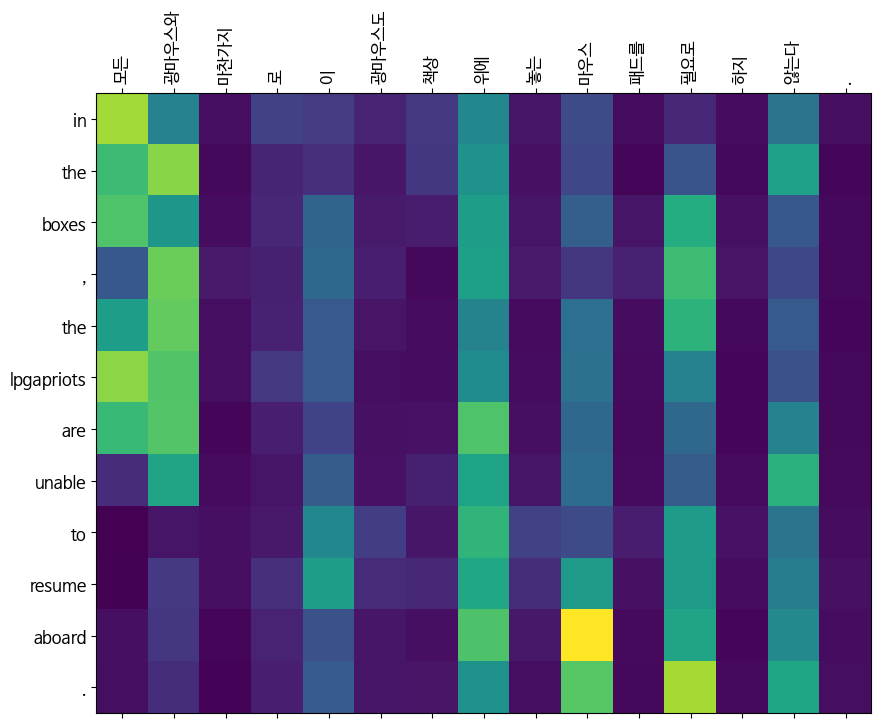

In [45]:
model = Seq2SeqAttention(encoder, decoder, device).to(device)

model.load_state_dict(torch.load('best_model_B.pth', map_location=device))

model.eval()

translate("모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 안녕하세요 . 우리 점심 뭐먹을까요 ?
Predicted translation: we re going to be a good  ⁇ 


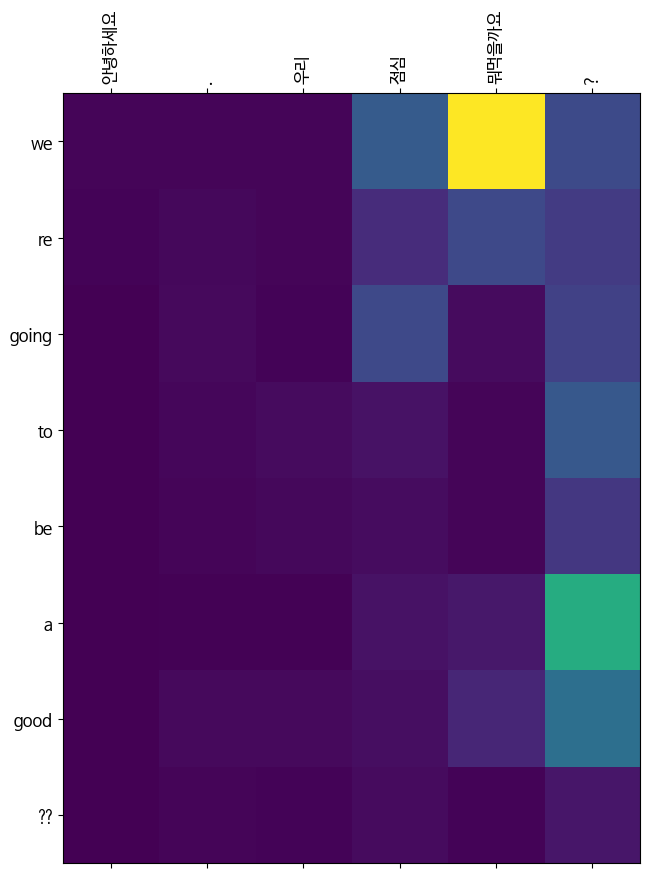

In [46]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

model.load_state_dict(torch.load('best_model_A.pth', map_location=device))

model.eval()

translate("안녕하세요. 우리 점심 뭐먹을까요?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: 안녕하세요 . 저희 점심 뭐먹을까요 ?
Predicted translation: we re going to be able to get the  ⁇ 50  ⁇ 


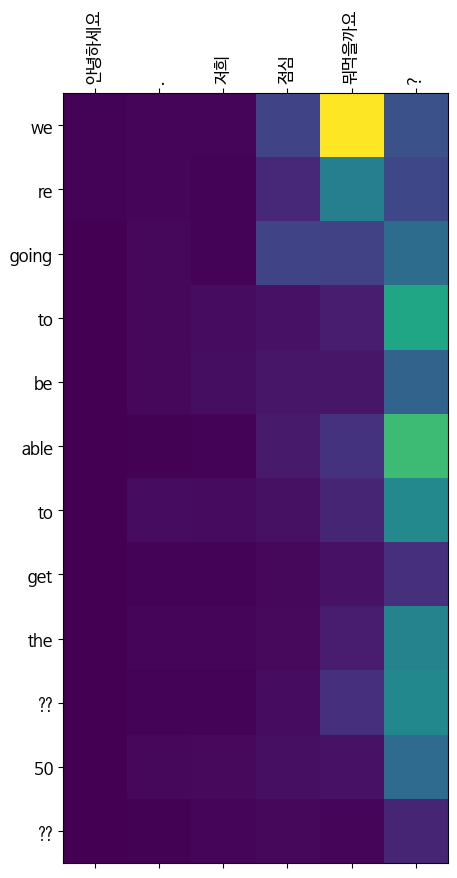

In [47]:
translate("안녕하세요. 저희 점심 뭐먹을까요?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

## 실험1 결과
- 최대 평균 Meteor: 0.2928

## 해석
- 양방향 인코더 적용 후 Meteor 점수 상승: 0.2837 -> 0.2928
- 아주 큰 변화는 없었지만, 점수 상승한 것으로 보아 효과가 있는 것으로 보임
- 아직도 완전히 번역을 잘하는 것 같진 않음

## 회고
- 아직 정확히 어떻게 정확도를 올려야할지는 잘 모르겠음
- 기존에 제공된 코드가 완전한 BahdanauAttention에 맞게 돼있는 것 같지는 않음
  - 살짝 하이브리드? Luong과 섞인듯
  - 그래서 완전한 BahdanauAttention로 리팩토링 해도 괜찮을 것 같음